# Лаб №1
## Вариационные ряды и выборочная функция распределения

##  задание

Для непрерывной и дискретной выборок построить вариационные ряды, найти выборочные
функции распределения и построить их графики.

##  данные

Непрерывная выборка объёма `n = 26`:

```text
10.20, 9.23, 8.77, 10.40, 9.44, 9.09, 6.30, 9.42, 6.12, 9.69, 8.59, 8.68, 7.97, 8.64, 6.45, 5.29, 5.00, 8.42, 8.84, 8.26, 6.66, 6.96, 6.51, 6.72, 6.00, 5.36
```

Дискретная выборка объёма `n = 30`:

```text
2, 3, 2, 1, 2, 2, 4, 0, 2, 4, 4, 0, 1, 5, 1, 1, 3, 2, 2, 1, 4, 2, 2, 0, 1, 2, 4, 2, 0, 2
```



- **Дискретный вариационный ряд**: упорядоченные различные значения выборки $x_{(1)} < x_{(2)} < \dots < x_{(N)}$ и их частоты $n_i$.
- **Относительная частота**: $\omega_i = \frac{n_i}{n}$.
- **Интервальный вариационный ряд**: разбиение диапазона значений на интервалы одинаковой длины $\Delta$.
- **Эмпирическая функция распределения**:

$$
F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\{x_i \le x\}.
$$

Она является ступенчатой неубывающей функцией, а величина скачка в точке варианта равна его относительной частоте.


In [85]:
import math
import numpy as np
import matplotlib.pyplot as plt




discrete = [2, 3, 2, 1, 2, 2, 4, 0, 2, 4, 4, 0, 1, 5, 1, 1, 3, 2, 2, 1, 4, 2, 2, 0, 1, 2, 4, 2, 0, 2]
continuous = [10.2, 9.23, 8.77, 10.4, 9.44, 9.09, 6.30, 9.42, 6.12, 9.69, 8.59, 8.68, 7.97, 8.64, 6.45, 5.29, 5.00, 8.42, 8.84, 8.26, 6.66, 6.96, 6.51, 6.72, 6.00, 5.36]


In [86]:


def discrete_series(sample):
    arr = np.asarray(sample, dtype=int)
    # values — массив уникальных элементов, counts — массив их количеств.
    values, counts = np.unique(arr, return_counts=True)
    ot_chastot = counts / arr.size

    nakop_chastoti = np.cumsum(ot_chastot)

    plotnost = ot_chastot

    # Возвращаем все рассчитанные массивы для дальнейшего построения графиков и таблиц
    return values, counts, ot_chastot, nakop_chastoti, plotnost


def interval_series(sample, intervals=5):
    arr = np.asarray(sample, dtype=float)
    edges = np.linspace(arr.min(), arr.max(), intervals + 1)

    counts, _ = np.histogram(arr, bins=edges)
    ot_chastot = counts / arr.size

    nakop_chastoti = np.cumsum(ot_chastot)

    mids = (edges[:-1] + edges[1:]) / 2

    plotnost = ot_chastot / np.diff(edges)

    # Возвращаем все вычисленные параметры интервального ряда
    return edges, mids, counts, ot_chastot, nakop_chastoti, plotnost


In [87]:


values, counts, ot_chastot_disc, nakop_chastoti_disc, plotnost_disc = (
    discrete_series(discrete)
)
edges, mids, icounts, ot_chastot_int, nakop_chastoti_int, plotnost_int = (
    interval_series(continuous, intervals=5)
)

# --- ВЫВОД ДИСКРЕТНОГО РЯДА ---
print("=" * 50)
print("ДИСКРЕТНЫЙ ВАРИАЦИОННЫЙ РЯД")
print("=" * 50)
print(
    f"{'x_i':>5} | {'n_i':>5} | {'w_i (Частость)':>14} | {'F_n(x) (Накопл.)':>16}"
)
print("-" * 50)
# Используем новые имена переменных: ot_chastot_disc и nakop_chastoti_disc
for v, c, r, k in zip(values, counts, ot_chastot_disc, nakop_chastoti_disc):
    print(f"{v:>5} | {c:>5} | {r:>14.4f} | {k:>16.4f}")
print("=" * 50)
print(f"Итого: N = {counts.sum()}\n\n")

# --- ВЫВОД ИНТЕРВАЛЬНОГО РЯДА ---
print("=" * 65)
print("ИНТЕРВАЛЬНЫЙ ВАРИАЦИОННЫЙ РЯД")
print("=" * 65)
print(
    f"{'Интервал (x_i; x_i+1]':>22} | {'n_i':>5} | {'w_i (Частость)':>14} | {'F_n(x)':>10}"
)
print("-" * 65)
# Используем новые имена переменных: icounts, ot_chastot_int и nakop_chastoti_int
for i in range(len(icounts)):
    interval_str = f"[{edges[i]:.2f}; {edges[i+1]:.2f})"
    print(
        f"{interval_str:>22} | {icounts[i]:>5} | {ot_chastot_int[i]:>14.4f} | {nakop_chastoti_int[i]:>10.4f}"
    )
print("=" * 65)
print(f"Итого: N = {icounts.sum()}")

ДИСКРЕТНЫЙ ВАРИАЦИОННЫЙ РЯД
  x_i |   n_i | w_i (Частость) | F_n(x) (Накопл.)
--------------------------------------------------
    0 |     4 |         0.1333 |           0.1333
    1 |     6 |         0.2000 |           0.3333
    2 |    12 |         0.4000 |           0.7333
    3 |     2 |         0.0667 |           0.8000
    4 |     5 |         0.1667 |           0.9667
    5 |     1 |         0.0333 |           1.0000
Итого: N = 30


ИНТЕРВАЛЬНЫЙ ВАРИАЦИОННЫЙ РЯД
 Интервал (x_i; x_i+1] |   n_i | w_i (Частость) |     F_n(x)
-----------------------------------------------------------------
          [5.00; 6.08) |     4 |         0.1538 |     0.1538
          [6.08; 7.16) |     7 |         0.2692 |     0.4231
          [7.16; 8.24) |     1 |         0.0385 |     0.4615
          [8.24; 9.32) |     9 |         0.3462 |     0.8077
         [9.32; 10.40) |     5 |         0.1923 |     1.0000
Итого: N = 26


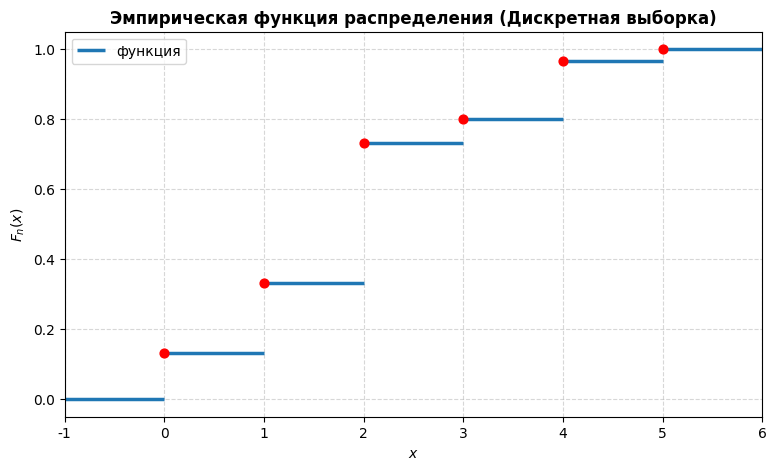

In [ ]:

plt.figure(figsize=(9, 5))

x_min_bound = values[0] - 1
x_max_bound = values[-1] + 1

plt.hlines(0, x_min_bound, values[0], colors="#1f77b4", linewidth=2.5, label="функция")

for i in range(len(values) - 1):
    plt.hlines(nakop_chastoti_disc[i], values[i], values[i+1], colors="#1f77b4", linewidth=2.5)

plt.hlines(1, values[-1], x_max_bound, colors="#1f77b4", linewidth=2.5)



plt.scatter(values, nakop_chastoti_disc, color="red", zorder=3, s=40)


plt.title("Эмпирическая функция распределения (Дискретная выборка)", fontsize=12, fontweight='bold')
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$F_n(x)$", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

plt.xlim(x_min_bound, x_max_bound)
plt.ylim(-0.05, 1.05)

# Чтобы лейбл в легенде не дублировался из-за цикла, берем только уникальные
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend([handles[0]], [labels[0]], loc="upper left")

plt.show()

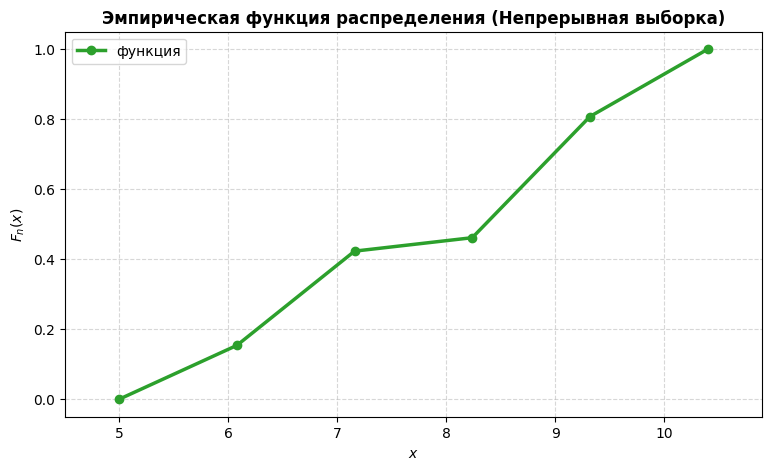

In [89]:
plt.figure(figsize=(9, 5))

# Для интервального ряда график начинается с 0 на левой границе первого интервала
x_cont = edges
y_cont = np.concatenate(([0], nakop_chastoti_int))

# Строим кумулятивную ломаную линию
plt.plot(x_cont, y_cont, marker="o", color="#2ca02c", linewidth=2.5, label="функция")

plt.title("Эмпирическая функция распределения (Непрерывная выборка)", fontsize=12, fontweight='bold')
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$F_n(x)$", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(edges[0] - 0.5, edges[-1] + 0.5)
plt.ylim(-0.05, 1.05)
plt.legend(loc="upper left")

plt.show() # Вывод второго графика в блокноте